# Desenvolvimento de um Modelo Preditivo para Classificação de Níveis de Obesidade com Base em Fatores Comportamentais e Demográficos

Este projeto tem como objetivo desenvolver um modelo preditivo baseado em técnicas de Machine Learning para auxiliar profissionais da saúde na classificação dos níveis de obesidade. O modelo utiliza variáveis comportamentais e demográficas como preditores, buscando identificar padrões associados à progressão da condição. A proposta visa contribuir para estratégias de prevenção e intervenções personalizadas, apoiando decisões clínicas baseadas em dados.

## 1. Preparação do Ambiente e Extração dos Dados

### 1.1 Importação das Dependências e Bibliotecas

In [92]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Conexão com banco
import sqlite3
import os

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelagem
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Avaliação
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Persistência
import joblib

### 1.2 Acesso à Base de Dados Relacionais (SQLite)

Nesta etapa, é estabelecida a conexão com o banco de dados relacional SQLite, responsável pela persistência dos registros hospitalares. A extração dos dados é realizada por meio de consulta SQL à tabela de pacientes, garantindo reprodutibilidade e rastreabilidade das informações utilizadas na modelagem.

In [93]:
conn = sqlite3.connect('../data/hospital.db')

query = "SELECT * FROM pacientes"
df = pd.read_sql(query, conn)

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


A visualização inicial dos dados permite verificar a estrutura da base, identificar os tipos de variáveis (numéricas e categóricas) e confirmar a correta importação dos registros. 

## 2. Data Cleaning e Validação da Base

Antes da modelagem, é fundamental avaliar a qualidade da base de dados. Nesta etapa, são verificados possíveis valores ausentes (missing values), que podem comprometer a performance do modelo ou introduzir viés estatístico caso não sejam tratados adequadamente.

### 2.1 Verificação de Valores Ausentes e Registros Duplicados

In [94]:
# Verificar valores nulos
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


A análise indica ausência de valores nulos na base, o que elimina a necessidade de estratégias de imputação e reduz a complexidade do pré-processamento.

Em seguida, verifica-se a existência de registros duplicados, que podem distorcer a distribuição das classes e afetar a capacidade de generalização do modelo.

In [95]:
# Verificar linhas duplicadas
print("Total de linhas duplicadas: ", df.duplicated().sum())

Total de linhas duplicadas:  24


Foram identificados registros duplicados na base. A manutenção dessas observações poderia levar à super-representação de determinados perfis, comprometendo a validade do modelo.

In [96]:
# Remoção das linhas duplicadas
df = df.drop_duplicates()

Os registros duplicados foram removidos para garantir a integridade estatística da base, evitando vieses decorrentes de múltiplas ocorrências idênticas.

### 2.2 Verificação dos Tipos e Estrutura das Variáveis

A função df.info() foi utilizada para verificar a estrutura da base de dados, incluindo o número de observações, variáveis disponíveis, tipos de dados e consistência quanto à presença de valores não nulos.

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), object(9)
memory usage:

A base contém 2.087 observações e 17 variáveis, das quais 8 são numéricas (float64) e 9 categóricas (object).

As variáveis numéricas incluem características antropométricas (Age, Height, Weight) e indicadores quantitativos de hábitos comportamentais (FCVC, NCP, CH2O, FAF, TUE). Já as variáveis categóricas representam atributos demográficos e padrões de consumo, que exigirão codificação apropriada antes da modelagem.

Destaca-se que a variável Obesity constitui a variável alvo (target), caracterizando o problema como uma tarefa de classificação supervisionada multiclasse.

## 3. Análise Exploratória dos Dados

### 3.1 Interpretação Estatística

In [98]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


A estatística descritiva das variáveis numéricas permite compreender a distribuição central e dispersão dos dados. Observa-se que a idade média dos indivíduos é de aproximadamente 24 anos, indicando uma população predominantemente jovem.

O peso apresenta média de 86,86 kg e desvio padrão de 26,19 kg, sugerindo elevada variabilidade entre os indivíduos — aspecto coerente com a existência de múltiplas categorias de obesidade na variável alvo.

Nota-se ainda ampla variação nos níveis de atividade física (FAF) e tempo de uso de dispositivos eletrônicos (TUE), indicando heterogeneidade nos hábitos comportamentais da amostra.


### 3.2 Distribuição da Variável Alvo (Obesity)

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_28828\638942128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Obesity', palette='magma', order=df['Obesity'].value_counts().index)


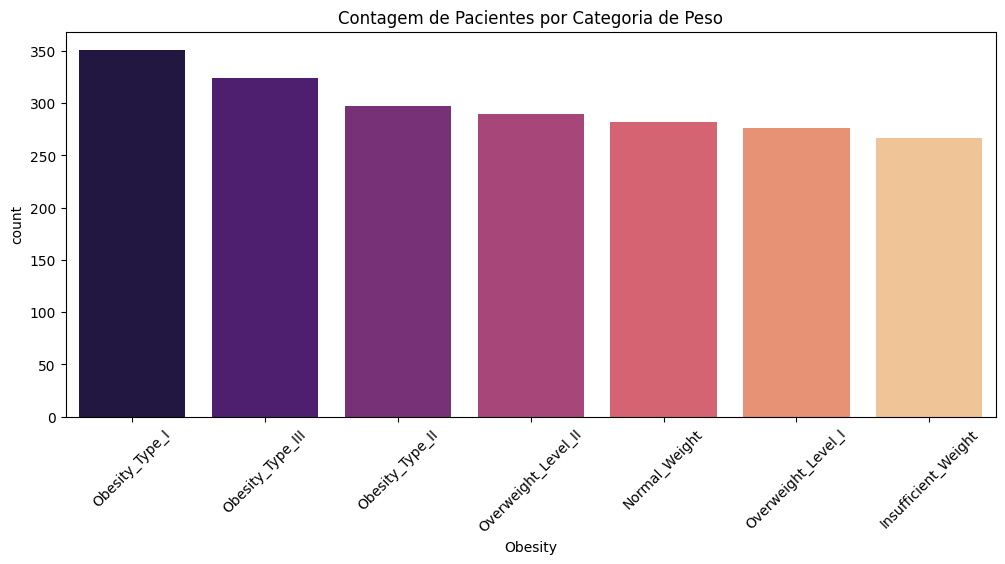

In [99]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Obesity', palette='magma', order=df['Obesity'].value_counts().index)
plt.title('Contagem de Pacientes por Categoria de Peso')
plt.xticks(rotation=45)
plt.show()

A distribuição das classes indica relativo equilíbrio entre as categorias de peso, reduzindo o risco de viés associado a classes majoritárias durante o treinamento do modelo.

### 3.3 Perfil Demográfico e Antropométrico da Amostra

Text(0.5, 1.0, 'Distribuição de Idade dos Pacientes')

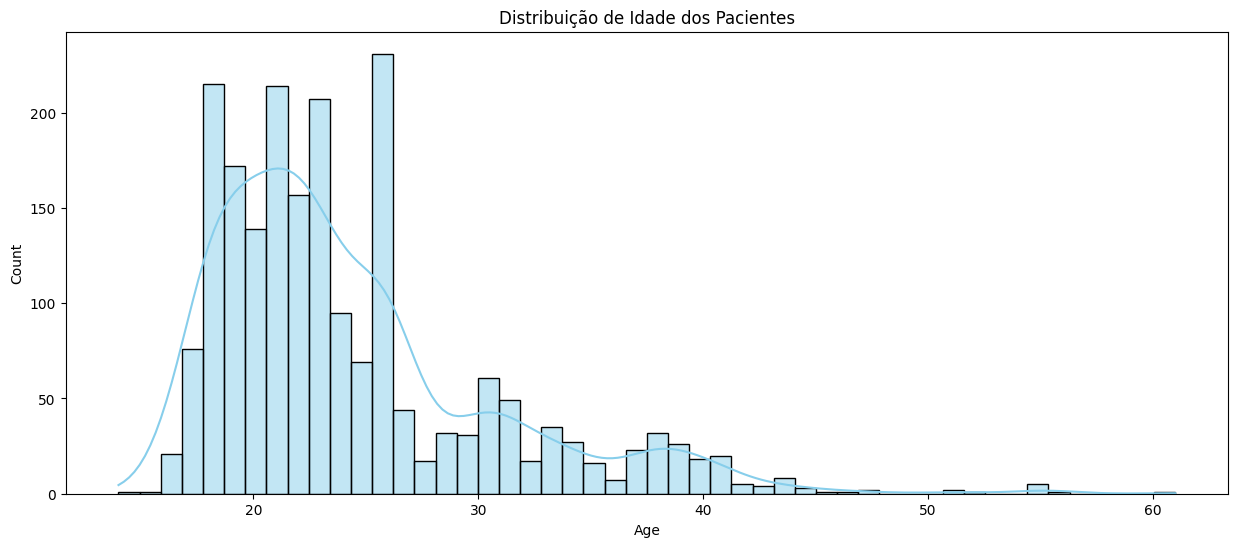

In [100]:
# Distribuição de idade

fig, ax = plt.subplots(figsize=(15, 6))

sns.histplot(df['Age'], kde=True, ax=ax, color='skyblue')
ax.set_title('Distribuição de Idade dos Pacientes')

A distribuição etária indica concentração significativa de indivíduos entre aproximadamente 18 e 25 anos, com declínio progressivo nas faixas etárias superiores.

Essa característica sugere que o modelo poderá apresentar melhor capacidade preditiva para populações jovens-adultas, devendo-se ter cautela na generalização para faixas etárias mais elevadas.

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_28828\3963222642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Weight', ax=ax, palette='Set2')


Text(0.5, 1.0, 'Distribuição de Peso por Gênero')

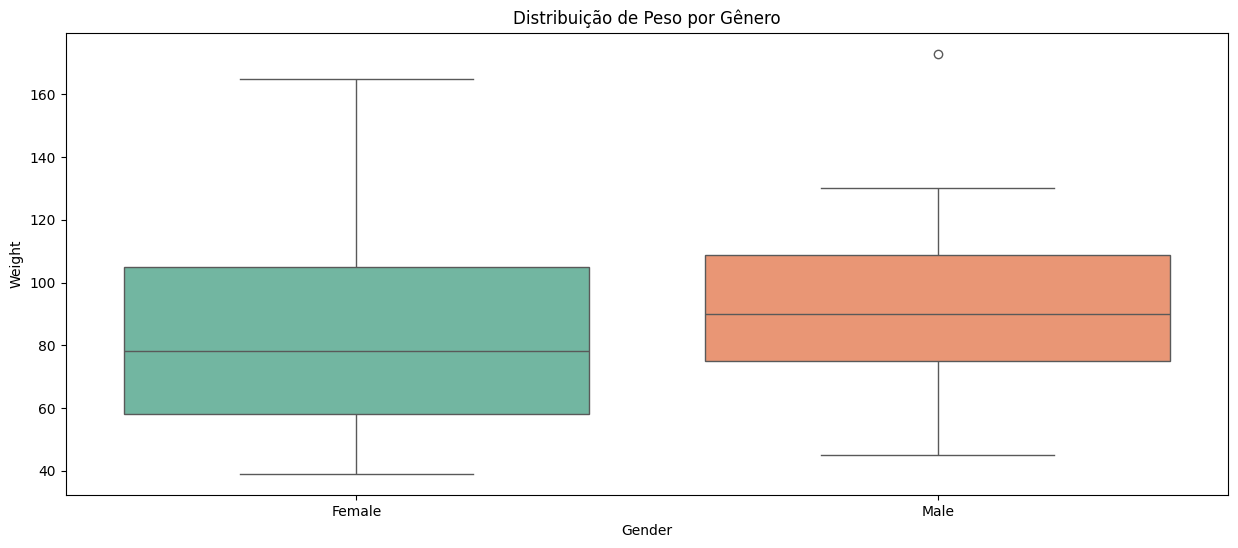

In [101]:
# Boxplot de peso por gênero

fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(data=df, x='Gender', y='Weight', ax=ax, palette='Set2')
ax.set_title('Distribuição de Peso por Gênero')

Observa-se que o grupo masculino apresenta mediana de peso ligeiramente superior ao grupo feminino, além de maior dispersão dos valores.

Nota-se a presença de valores extremos (outliers), especialmente no grupo masculino, com indivíduos apresentando peso significativamente acima do intervalo interquartil.

Embora algoritmos baseados em árvores, como Random Forest, sejam relativamente robustos a outliers, é importante considerar seu impacto potencial na modelagem, especialmente em variáveis contínuas com grande amplitude.

## 4. Engenharia de Atributos e Alinhamento às Regras de Negócio

### 4.1 Ajuste de Variáveis Ordinais com Ruído Decimal

As variáveis FCVC, NCP, CH2O, FAF e TUE representam escalas discretas ordinalizadas no instrumento original de coleta. No entanto, observou-se a presença de valores decimais, possivelmente decorrentes de processos de interpolação ou normalização prévia do dataset.

Considerando que essas variáveis correspondem a categorias discretas, optou-se pelo arredondamento para o inteiro mais próximo, restabelecendo a coerência semântica das escalas e reduzindo ruído estatístico.

In [102]:
# Arredondando os valores com ruído decimal
cols_ruido = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[cols_ruido] = df[cols_ruido].round().astype(int)

In [103]:
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f'{col}: {valores_unicos}')
    print('---')

Gender: ['Female' 'Male']
---
Age: [21.       23.       27.       ... 22.524036 24.361936 23.664709]
---
Height: [1.62     1.52     1.8      ... 1.752206 1.73945  1.738836]
---
Weight: [ 64.        56.        77.       ... 133.689352 133.346641 133.472641]
---
family_history: ['yes' 'no']
---
FAVC: ['no' 'yes']
---
FCVC: [2 3 1]
---
NCP: [3 1 4 2]
---
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
---
SMOKE: ['no' 'yes']
---
CH2O: [2 3 1]
---
SCC: ['no' 'yes']
---
FAF: [0 3 2 1]
---
TUE: [1 0 2]
---
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
---
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
---
Obesity: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']
---


### 4.2 Padronização Semântica e Localização das Variáveis

Realizou-se a tradução dos nomes das variáveis e de seus respectivos valores categóricos com o objetivo de garantir consistência semântica entre o dataset de treinamento e a interface do aplicativo desenvolvido em Streamlit.

Essa padronização assegura alinhamento entre os dados de entrada fornecidos pelo usuário e os atributos utilizados pelo modelo, reduzindo riscos de inconsistência operacional.

In [104]:
# Tradução das colunas
colunas_pt = {
    'Gender': 'genero', 'Age': 'idade', 'Height': 'altura', 'Weight': 'peso',
    'family_history': 'historico_familiar', 'FAVC': 'consumo_alimento_calorico',
    'FCVC': 'freq_consumo_vegetais', 'NCP': 'num_refeicoes', 'CAEC': 'consumo_entre_refeicoes', 'SMOKE': 'fumante',
    'CH2O': 'consumo_agua', 'SCC': 'monitora_caloria', 'FAF': 'freq_atividade_fisica', 'TUE': 'tempo_tela', 'CALC': 'consumo_alcool',
    'MTRANS': 'meio_transporte', 'Obesity': 'diagnostico'
}

df.rename(columns=colunas_pt, inplace=True)

In [105]:
df.columns

Index(['genero', 'idade', 'altura', 'peso', 'historico_familiar',
       'consumo_alimento_calorico', 'freq_consumo_vegetais', 'num_refeicoes',
       'consumo_entre_refeicoes', 'fumante', 'consumo_agua',
       'monitora_caloria', 'freq_atividade_fisica', 'tempo_tela',
       'consumo_alcool', 'meio_transporte', 'diagnostico'],
      dtype='object')

In [106]:
# Tradução dos valores internos e do target
mapa_valores = {
    'genero': {'Female': 'Feminino', 'Male': 'Masculino'},
    'historico_familiar': {'yes': 'Sim', 'no': 'Não'},
    'consumo_alimento_calorico': {'yes': 'Sim', 'no': 'Não'},
    'fumante': {'yes': 'Sim', 'no': 'Não'},
    'monitora_caloria': {'yes': 'Sim', 'no': 'Não'},
    'consumo_entre_refeicoes': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'consumo_alcool': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'meio_transporte': {'Automobile': 'Carro', 'Motorbike': 'Moto', 'Bike': 'Bicicleta', 'Public_Transportation': 'Transporte público', 'Walking': 'A pé'},
    'diagnostico': {
        'Insufficient_Weight': 'Abaixo do Peso',
        'Normal_Weight': 'Peso Normal',
        'Overweight_Level_I': 'Sobrepeso Nível I',
        'Overweight_Level_II': 'Sobrepeso Nível II',
        'Obesity_Type_I': 'Obesidade Tipo I',
        'Obesity_Type_II': 'Obesidade Tipo II',
        'Obesity_Type_III': 'Obesidade Tipo III'
    },
    # Mapeamento das escalas para o padrão de texto do app no Streamlit
    'consumo_agua': {1: 'Menos de 1 litro por dia', 2: 'De 1 a 2 litros por dia', 3: 'Mais de 2 litros por dia'},
    'freq_atividade_fisica': {0: 'Nenhuma', 1: '1 a 2 vezes por semana', 2: '3 a 4 vezes por semana', 3: '5 ou mais vezes por semana'},
    'tempo_tela': {0: '0 a 2 horas por dia', 1: '3 a 5 horas por dia', 2: 'Mais de 5 horas por dia'},
    'freq_consumo_vegetais': {1: 'Raramente', 2: 'Às vezes', 3: 'Sempre'},
    'num_refeicoes': {
        1: '1 refeição', 
        2: '2 refeições', 
        3: '3 refeições', 
        4: '4 ou mais refeições'
    }
}

df.replace(mapa_valores, inplace=True)

In [107]:
df.head(1)

,genero,idade,altura,peso,historico_familiar,consumo_alimento_calorico,freq_consumo_vegetais,num_refeicoes,consumo_entre_refeicoes,fumante,consumo_agua,monitora_caloria,freq_atividade_fisica,tempo_tela,consumo_alcool,meio_transporte,diagnostico
0,Feminino,21.0,1.62,64.0,Sim,Não,Às vezes,3 refeições,Consome às vezes,Não,De 1 a 2 litros por dia,Não,Nenhuma,3 a 5 horas por dia,Não consome,Transporte público,Peso Normal


### 4.3 Seleção de Variáveis e Mitigação de Viés

Durante a modelagem exploratória preliminar, observou-se que a variável meio_transporte apresentava elevada importância preditiva segundo a métrica de importância de atributos do modelo baseado em árvores.

Entretanto, essa variável pode funcionar como proxy de condições socioeconômicas estruturais, não diretamente modificáveis em contexto clínico. Considerando o objetivo do projeto — desenvolver uma ferramenta de apoio à decisão orientada a fatores comportamentais e biométricos — optou-se por sua exclusão.

A decisão visa mitigar potenciais vieses estruturais e evitar que o modelo incorpore determinantes indiretos de desigualdade social como fatores centrais de classificação.

In [108]:
# Remoção da variável 'meio_transporte'
df = df.drop('meio_transporte', axis=1)

## 5. Persistência do Dataset Tratado

Após as etapas de limpeza, padronização e engenharia de atributos, o dataset consolidado foi exportado para persistência em formato CSV.

Essa etapa garante reprodutibilidade do processo, separação entre preparação de dados e aplicação final, além de permitir a utilização da base tratada no painel de visualização e na interface da aplicação desenvolvida.

In [109]:
df_export = df.copy()

if not os.path.exists('../data'):
    os.makedirs('../data')

df_export.to_csv('../data/obesity_cleaned.csv', index=False)

print('Arquivo obesity_cleaned.csv gerado com sucesso!')

Arquivo obesity_cleaned.csv gerado com sucesso!


## 6. Pipeline de Pré-Processamento e Treinamento do Modelo

### 6.1 Separação de X e y

In [110]:
# Separando as Variáveis
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

### 6.2 Divisão Treino/Teste

In [111]:
# Dividindo em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (1669, 15)
X_test: (418, 15)


### 6.3 Pipeline de Pré-Processamento

Foi utilizado o conceito de Pipeline do scikit-learn para encapsular as etapas de pré-processamento e modelagem em um único fluxo computacional.

Essa abordagem garante que transformações como codificação ordinal e padronização sejam ajustadas exclusivamente com base nos dados de treino, sendo posteriormente aplicadas aos dados de teste sem acesso prévio às suas distribuições, prevenindo assim o data leakage.

O algoritmo Random Forest foi selecionado devido à sua robustez, capacidade de modelar relações não lineares e menor sensibilidade a escalas de variáveis.

In [112]:
# Listas de categorias ordinais na ordem correta
ordem_caec_calc = ['Não consome', 'Consome às vezes', 'Consome frequentemente', 'Consome sempre']
ordem_fcvc = ['Raramente', 'Às vezes', 'Sempre']
ordem_ch2o = ['Menos de 1 litro por dia', 'De 1 a 2 litros por dia', 'Mais de 2 litros por dia']
ordem_faf  = ['Nenhuma', '1 a 2 vezes por semana', '3 a 4 vezes por semana', '5 ou mais vezes por semana']
ordem_tue  = ['0 a 2 horas por dia', '3 a 5 horas por dia', 'Mais de 5 horas por dia']
ordem_ncp = ['1 refeição', '2 refeições', '3 refeições', '4 ou mais refeições']

In [113]:
# Padronização
preprocessor = ColumnTransformer(
    transformers = [
        ('ord_especifico', OrdinalEncoder(categories=[
            ordem_caec_calc, ordem_caec_calc, ordem_fcvc, ordem_ch2o, ordem_faf, ordem_tue, ordem_ncp
        ]), ['consumo_entre_refeicoes', 'consumo_alcool', 'freq_consumo_vegetais', 'consumo_agua', 'freq_atividade_fisica', 'tempo_tela', 'num_refeicoes']),

        ('bin_nom', OrdinalEncoder(), ['genero', 'historico_familiar', 'consumo_alimento_calorico', 'fumante', 'monitora_caloria']),

        ('num', StandardScaler(), ['idade', 'altura', 'peso'])
    ]
)

A padronização foi mantida visando eventual comparação futura com modelos sensíveis à escala, como regressão logística ou SVM.

In [114]:
# Montando a pipeline final (que terá efeito tanto no dataset de treino quanto nos dados vindos do app final)
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

### 6.4 Treinamento do Modelo

In [115]:
# Treinamento
pipeline_final.fit(X_train, y_train)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


### 6.5 Extração das Importâncias

In [116]:
# Extraindo os pesos das variáveis
modelo_final = pipeline_final.named_steps['model']
importancias = modelo_final.feature_importances_
nomes_colunas = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Peso': importancias
}).sort_values(by='Peso', ascending=False)

# Salvar para o app usar
df_importancia.to_csv('../data/features_importance.csv', index=False)

## 7. Avaliação de Desempenho e Capacidade de Generalização

Após o treinamento do modelo utilizando o pipeline estruturado com pré-processamento encapsulado, procedeu-se à avaliação de desempenho em dados de teste não vistos durante o ajuste do modelo.

### 7.1 Acurácia Global

In [117]:
acuracia = pipeline_final.score(X_test, y_test)
print(f'Acurácia global: {acuracia:.2%}')

Acurácia global: 94.50%


A acurácia representa a proporção total de previsões corretas realizadas pelo modelo sobre o conjunto de teste.

Considerando que o problema envolve 7 classes distintas, uma acurácia de 94,50% indica elevada capacidade discriminativa.

No entanto, em problemas multiclasse, a acurácia isoladamente não é suficiente para avaliar o desempenho, sendo necessária análise detalhada por classe.

### 7.2 Matriz de Confusão

<Figure size 1000x800 with 0 Axes>

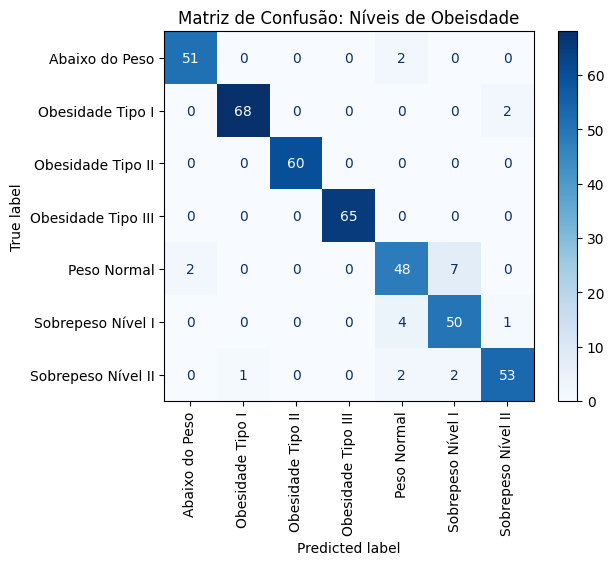

In [118]:
y_pred = pipeline_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Matriz de Confusão: Níveis de Obeisdade')
plt.show()

### 7.3 Classification Report

In [119]:
y_pred = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred, target_names=np.unique(y_test)))

                    precision    recall  f1-score   support

    Abaixo do Peso       0.96      0.96      0.96        53
  Obesidade Tipo I       0.99      0.97      0.98        70
 Obesidade Tipo II       1.00      1.00      1.00        60
Obesidade Tipo III       1.00      1.00      1.00        65
       Peso Normal       0.86      0.84      0.85        57
 Sobrepeso Nível I       0.85      0.91      0.88        55
Sobrepeso Nível II       0.95      0.91      0.93        58

          accuracy                           0.94       418
         macro avg       0.94      0.94      0.94       418
      weighted avg       0.95      0.94      0.95       418



### 7.4 Análise Técnica das Métricas

**Classes Extremas:**
* As categorias relacionadas a quadros mais definidos (baixo peso e obesidades grau II e III) apresentaram desempenho ótimo.
* Isso indica que o modelo identifica com alta confiabilidade casos clinicamente mais evidentes.

**Classes Intermediárias:**
* Os menores valores de recall concentram-se em Sobrepeso Nível I/II e Peso Normal
    * Esse comportamento é coerente com a proximidade fisiológica entre essas categorias, cuja fronteiras são mais sensíveis a pequenas variações antropométricas

### 7.5 Análise das Médias Macro e Ponderada

A proximidade entre Macro Average (0.94) e Weighted Average (0.95) indica que:
* O dataset apresenta distribuição relativamente equilibrada entre as classes
* O modelo não favorece uma classe específica
* Não há viés significativo na classificação

### 7.6 Capacidade de Generalização

A avaliação foi realizada em dados não utilizados no treinamento, preservando:
* Separação estratificada
* Encapsulamento do pré-processamento via Pipeline
* Ausência de vazamento de informação

A manutenção do desempenho elevado no conjunto de teste sugere boa capacidade de generalização.

### 7.7 Síntese da Avaliação

O modelo apresentou:
* Alta acurácia global (94,50%)
* Excelente equilíbrio entre classes
* Erros concentrados em categorias adjacentes
* Comportamento coerente com critérios clínicos

Conclui-se que o pipeline construído demonstra elevada capacidade discriminativa e estabilidade preditiva, sendo adequado para integração na aplicação final proposta.

## 8. Serialização e Preparação para Produção

Após o treinamento e validação do modelo, o pipeline completo — contendo todas as etapas de pré-processamento e o modelo final — foi serializado para utilização em ambiente de produção.

A serialização foi realizada utilizando a biblioteca joblib, amplamente empregada para persistência de objetos treinados em projetos de Machine Learning desenvolvidos com scikit-learn.

A aplicação final foi desenvolvida com Streamlit, que utilizará o modelo serializado como motor de inferência em tempo real.

In [120]:
# Criar uma pasta chamada 'models'
if not os.path.exists('../models'):
    os.makedirs('models')

In [121]:
# Salvar o Pipeline completo (pré-processamento + modelo)
joblib.dump(pipeline_final, '../models/modelo_obesidade.pkl')

['../models/modelo_obesidade.pkl']

### 8.1 Justificativa da Serialização do Pipeline Completo

Optou-se por salvar o pipeline completo, e não apenas o modelo treinado, porque o objeto contém:
* Transformações ordinais
* Codificações categóricas
* Padronização numérica
* Modelo Random Forest ajustado

Essa abordagem garante que:
* O mesmo pré-processamento aplicado no treinamento seja replicado em produção
* Não haja inconsistência entre dados de treino e dados fornecidos pelo usuário
* O risco de data leakage ou transformação divergente seja eliminado